# Plot Learning Curves

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob

from pmind.learning_curves import (
    plot_learning_curves,
    plot_rb_compositions
)

%load_ext autoreload
%autoreload 2

In [2]:
ENV_NAMES = (
    # "CartPoleContinuous-v1",
    # "Pendulum-v1",
    "MountainCarContinuous-v0",
    # "LunarLanderContinuous-v3",
)
INPUT_DIR = "../results/test_rb_compositions-" + "selected"

In [3]:
ENV_NAME = "MountainCarContinuous-v0"

PROPORTIONS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
SEEDS = [0,1,2,4]#[0, 1, 2, 4]
EXPLOIT_REWARD = 35


def load_env_result(env_name, exploit_reward, proportions, seeds):
    d_ref = torch.load(
        f"../scripts/results/result-{env_name}-{exploit_reward}-{proportions[0]}-{seeds[0]}.pt",
        weights_only=False,
    )
    res = {
        "performances": None,
        "buffer_size": d_ref["buffer_size"],
        "rb_composition": proportions,
        "eval_interval": d_ref["eval_interval"],
        "cfg": d_ref["cfg"],
        "seeds": seeds,
        "type": d_ref["type"],
    }
    res["performances"] = [
        np.stack(
            [
                torch.load(
                    f"../scripts/results/result-MountainCarContinuous-v0-35-{proportion}-{seed}.pt",
                    weights_only=False,
                )["performances"]
                for seed in SEEDS
            ],
            -1,
        )
        for proportion in proportions
    ]
    return res


mcc_35 = load_env_result("MountainCarContinuous-v0", EXPLOIT_REWARD, PROPORTIONS, SEEDS)

In [4]:
# for i in range(len(SEEDS)):
#     plt.plot(mcc_35["performances"][2, :, :, i].mean(1))
# plt.show()

In [5]:
all_performances = {}
for rb_composition_type in ("uniform_proportions", "noise_levels"):
    all_performances[rb_composition_type] = {}
    for env_name in ENV_NAMES:
        all_performances[rb_composition_type][env_name] = {}
        print(f"{env_name}:")
        for intermediate_path in glob.glob(
            f"{INPUT_DIR}/{rb_composition_type}-{env_name}-scoring-*"
        ):
            exploit_performance = float(intermediate_path.split("-scoring-")[1])
            print(f"    {exploit_performance}")
            all_performances[rb_composition_type][env_name][exploit_performance] = (
                torch.load(intermediate_path, weights_only=False)
            )

MountainCarContinuous-v0:
MountainCarContinuous-v0:


In [6]:
all_performances["uniform_proportions"]["MountainCarContinuous-v0"][35] = mcc_35

=========== UNIFORM_PROPORTIONS =============


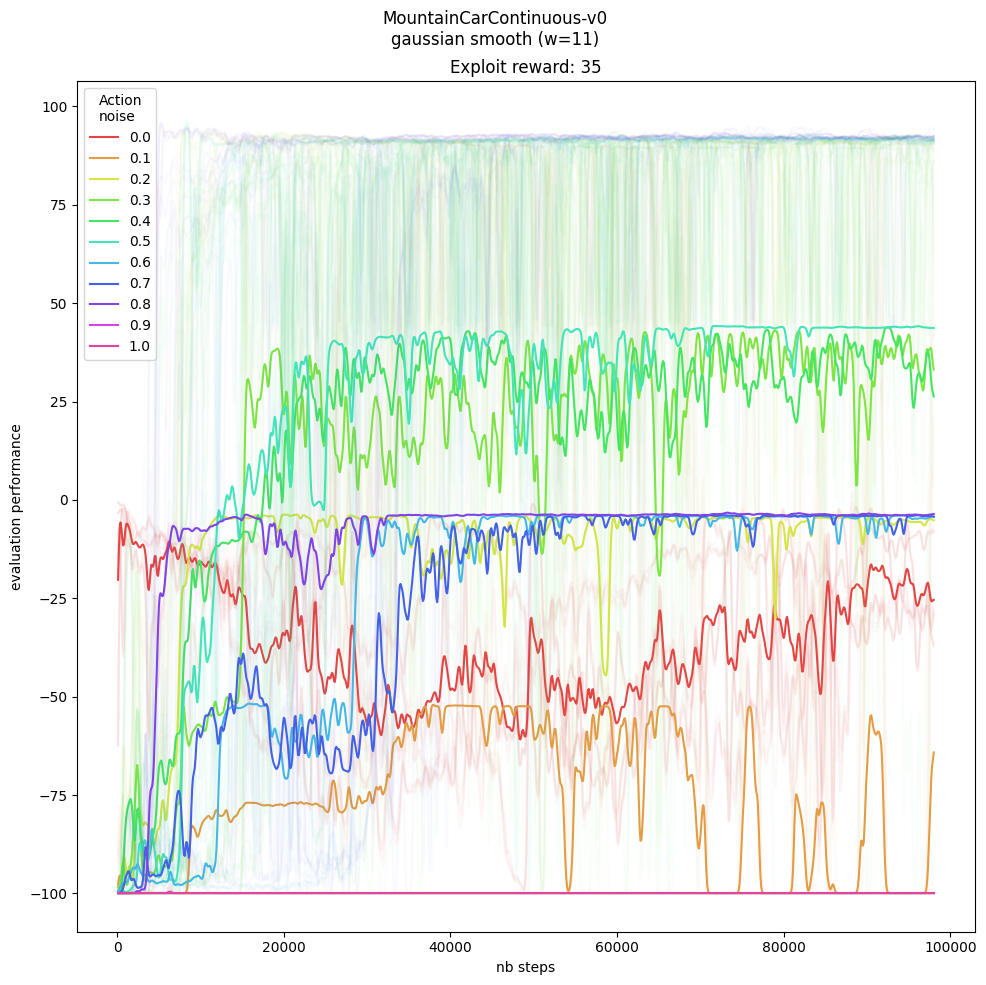

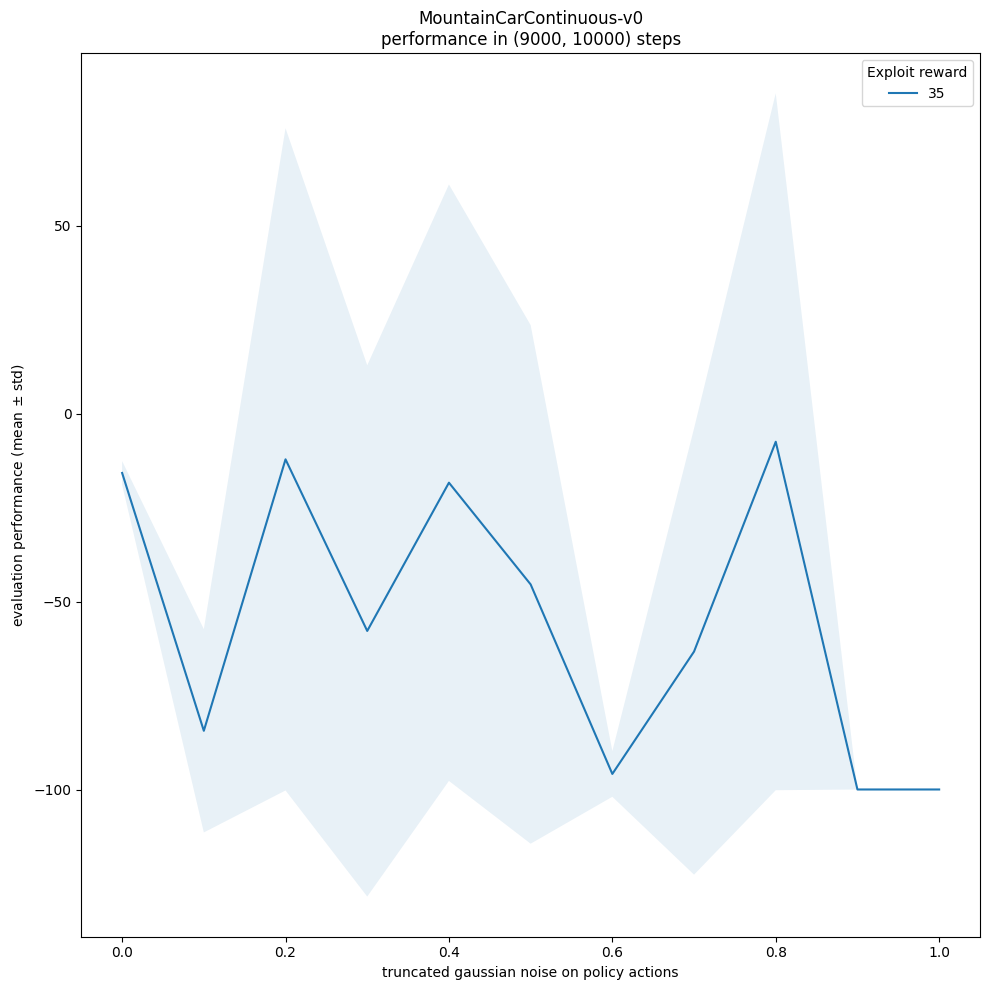

=========== NOISE_LEVELS =============


In [7]:
SMOOTH = True
SMOOTH_WINDOW = 11  # 11
SMOOTH_MODE = ("gaussian", "max")[0]
PLOT_ALL_CURVES = True
STEP_TO_TAKE = 10_000 #None  # 15_000
LAST_STEPS = 1000  # 500
PLOT_MARGIN = 0.05

last_performances = {}
std_last_performances = {}

for rb_composition_type in ("uniform_proportions", "noise_levels"):
    print("===========", rb_composition_type.upper(), "=============")
    for env_name in ENV_NAMES:
        if not all_performances[rb_composition_type][env_name]:
            continue

        last_performances[env_name] = {}
        std_last_performances[env_name] = {}
        
        env_performances = all_performances[rb_composition_type][env_name]
        plot_learning_curves(env_performances, SMOOTH_MODE,SMOOTH_WINDOW,PLOT_ALL_CURVES,PLOT_MARGIN)
        plot_rb_compositions(env_performances, SMOOTH_MODE,SMOOTH_WINDOW, STEP_TO_TAKE, LAST_STEPS)
        